In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma

In [1]:
x = np.array([0, 1, 2])
P = np.array([1/2, 1/4, 1/4])

plt.figure(figsize=(3,2))
plt.vlines(x, 0, P, colors='k', lw=4)
plt.xlabel(r"$x$")
plt.ylabel(r"$P(x)$")
plt.xlim(-0.5, 2.5)
plt.ylim(0, 0.55)
plt.xticks([0,1,2])
plt.yticks([0,0.25,0.5], [r"$0$", r"$1/4$", r"$1/2$"])
for spine in ['top','right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("figures_for_chapter_5/pmf.png", dpi=300, bbox_inches='tight')

NameError: name 'np' is not defined

# Entropy and the Second Law of Thermodynamics

```{admonition} Relevant readings and preparation:
:class: reading
- Concepts in Thermal Physics: Chapter 13 (13.1–13.3, 13.5), Chapter 14 (14.1–14.2, 14.5)
- University Physics with Modern Physics 15th edition: Chapter 20
- Introductory Statistics 2e: Chapter 1.1, 2.1 - 2.8, 3.1 - 3.3
- Entropy video: <https://www.youtube.com/watch?v=uQSoaiubuA0>
```

```{admonition} Learning outcomes:
:class: outcomes
- Distinguish reversible and irreversible thermodynamic processes
- Relate macroscopic irreversibility to microscopic disorder
- Define entropy from thermodynamic and statistical perspectives
- Connect entropy with probability
```

## Directions of Thermodynamic Processes

Thermodynamic processes in nature are **irreversible**, meaning they occur spontaneously in one direction only. Examples include heat flowing from hot to cold, the free expansion of a gas, and the conversion of mechanical energy into heat by friction. These processes define a preferred direction in nature, formalized by the **second law of thermodynamics**.

By contrast, **reversible processes** are idealized limits in which the system remains infinitesimally close to thermodynamic equilibrium at all times. Such processes can be reversed by an infinitesimal change in external conditions, for example when heat flows between bodies with nearly equal temperatures. Perfect reversibility cannot be achieved in practice, but real processes can approach it if temperature and pressure differences are made very small.

Irreversible processes are inherently nonequilibrium processes and cannot be made to run backward by small changes in conditions. Their direction is closely linked to increasing disorder: systems naturally evolve from more ordered states to more random ones. Mechanical energy represents organized motion, while heat corresponds to random molecular motion, so converting work into heat increases disorder and reinforces irreversibility.

```{figure} figures_for_chapter_5/Reversible_Processes.png
:width: 80%
:name: ice_in_metal_box
**(A)** A block of ice melts *irreversibly* when we place it into a hot (70 $^{\circ}$C) metal box, as heat flows from the box into the ice - inducing a phase change into water. The heat will never move from the colder body to the hotter one. **(B)** A block of ice at 0$^{\circ}$C can be melted *reversibly* if we put it in a 0$^{\circ}$C metal box. By infinitesimally raising or lowering the temperature of the box, so that we remain extremely close to the phase transition temperature of H$_2$O, we can make heat flow into the ice to melt it; or make heat flow out of the water to freeze it.
```

Examples will be provided once entropy is introduced. We will see that an irreversible process is characterized by a **positive change in the entropy of the universe**, whereas a reversible process corresponds to **zero total entropy change**.

## Entropy and Probability

Entropy $S$ is a concept associated with disorder, randomness and uncertainty. In thermodynamics, a system has a definite value of entropy for every particular state of the system - i.e., it is a state variable (as in {numref}`sec:state_vars`). A brief reminder - pressure and temperature are also state variables; heat and work are not. We can define entropy either thermodynamically ("Clausius" entropy) or statistically ("Gibbs"/"Boltzmann" entropy). 

```{admonition} Definition
:class: definition
Entropy is a measure of the uncertainty associated with a random variable.
```

If an outcome is highly unpredictable, its entropy is high, and its outcome is more likely to "surprise" you. Conversely, if an outcome is highly predictable, its entropy is low, and its outcome is less likely to "surprise" you.

To motivate the formalism of these definitions of entropy, we'll first introduce entropy in the context of information theory, via the **Shannon entropy**:

$$
H(X) = -\Sigma_i (p_i \log p_i),
$$ (computing)

- where $H$ is the weighted sum of surprises,
- $p_i$ is the probability (bounded by $(0, 1)$) of an event $i$,
- and $\log p_i$ quantifies the measurement or "surprise" of an event,

- further, the logarithm base determines units like so:
    - $\log_2$: "bits",
    - $\ln$: "nats",
    - $\log_{10}$: "bans".

For an event with $\Omega$ outcomes (specifically refers to states in the context of thermodynamics),

$$
p_i = \frac{1}{\Omega}.
$$

**Why do we take the logarithm in {eq}`computing`?**

To represent our variable, we want a function $f(p_i)$ where:
- for zero surprise, $f(p_i=1)=0$,
    - $\log(p_i = 1) = 0$
- for small p: $f(p_i)=\ \text{large}$,
    - $\log(p_i \ll 1) = \text{large and negative}$
- and where independent events sum together:
    - conveniently, $\log(a*b) = \log(a) + \log(b)$.

$$
\therefore f(p) = - \log(p).
$$

<!-- Let’s compare this to tossing a fair / unfair coin. -->
```{admonition} Example: Tossing an unfair coin
:class: example

What is the entropy in tossing an unfair coin (where both sides are heads)?

Since both sides are heads, the probability of an event's outcome is simply:
- $p(H) = 1.0$,
- $p(T) = 0.0$.
Seeing as we are certain of the outcome, we should expect $ S=0 $.

$$
\begin{aligned}
\to S &= - \Sigma_i p_i \ln p_i \\
&= - [p(H) \ln p(H) + p(T) \ln p(T)] \\
&= 0\ \text{bits of entropy}.
\end{aligned}
$$

With 0 bits of entropy, we can see there is $2^0=1$ modes.
```


```{admonition} Example: Tossing a fair coin
:class: example

What is the entropy in tossing a fair coin?

As above, but with different probabilities:
- $p(H) = p(T) = 0.5$.

$$
\begin{aligned}
\to S &= - \Sigma_i p_i \log_2 p_i \ \ \text{bits}\\
&= - [p(H) \log_2 p(H) + p(T) \log_2 p(T)] \\
&= - [.5 \log_2 0.5 + 0.5 \log_2 0.5] \\
&= - 0.5[\log_2 0.5 + \log_2 0.5] \\
&= - 0.5[\log_2 (0.5 \times 0.5)] \\
&= - 0.5[-\log_2 4] \\
&= - 0.5[-2] \\
&= 1\ \text{bit}.
\end{aligned}
$$

With 1 bit of entropy, we can see there are $2^1=2$ modes.
```

```{admonition} Example: Consecutive coin flips
:class: example

What is the entropy in tossing a fair coin four times?

The probability of getting 4 heads in a row with a fair coin is $P(4H)=2^{-4} = \frac{1}{16} = 6.25\% $ (least probable).
The probability of getting 2 heads and 2 tails is $P(2H, 2T) = \binom{4}{2}\cdot\frac{1}{4}^4= \frac{6}{16} = 37.5\%$ (most probable, see [[FIG]] for proof). 

The number of microscopic states grow rapidly with increasing number of coins. For $N=100$,

$$
P(100H) = \frac{1}{2}^{100} = 7.9\% \cdot 10^{-29}, \\
P(50H, 50T) = \binom{100}{50}\frac{1}{2}^{100} = 7.97\%.
$$

There is much greater entropy for 50 heads, 50 tails as there are many more combinations of microstates to describe the macrostate.
```

*NB: $\binom{n}{r} \equiv ^nC_r \equiv \frac{n!}{k!(n-k)!}$*

### Statistical form of entropy in thermodynamics

Consider an ideal gas containing Avagadro's number of molecules in two states (A) and (B):
- (A) has the gas being uniformly distributed,
- (B) has the gas being clustered together.

```{figure} figures_for_chapter_5/macroscopic_states.png
:name: red_ball
```

- Their macroscopic states are described by the state variables $T,\ p,\ V$.
- Both of their microscopic states are equally likely, however the macroscopic properties of $A$ and $B$ are different.
- (A) is more probable as there are more microscopic combinations of states that are able to describe the macrostate!

Let's consider the case where the gas is composed of $0.1 \text{mol} \to 6 \times 10^{22} \text{molecules}$.
- Case (A) might have $ 6 \times 10^{24} $ positions the molecules can occupy,
- Since case (B) has the molecules clustered together, they're restricted to a smaller subset of positions.

From {numref}`sec:combinatorials`, we know for case (A):

$$
\Omega_A = \binom{10^{24}}{10^{22}} \ \text{(for indistinguishable particles)}
$$

For case (B), there are fewer positions:

$$
\therefore \Omega_B = \binom{\text{pos}<10^{24}}{10^{22}} < \Omega_A
$$

This is where entropy is considered a measure of disorder, as state (A) is more disordered than state (B). However we can see that the underlying reason is that (A) is more probable as there are more combinations of microscopic states that describe its macrostate.

<!-- Gibbs and Boltzmann Entropy

(Section 20.8 + JL notes).

### Surprises and information

- Shannon entropy as a measure of uncertainty or surprise
- Card and deck-of-cards examples

Introduce **Gibbs entropy**, then specialize to **Boltzmann entropy**. -->

<!-- 
The **thermodynamic definition** considers the heat added over the course of a reversible process $Q_\text{rev}$:

$$
\Delta S = \int \frac{dQ_\text{rev}}{T},
$$ (stateful)

whereas the **statistical definition** (the  considers the microscopic distribution of the number of states $\Omega$: -->

<!-- These are both correct and equivalent, and should be used in accordance to what information is available to you. -->

(sec:stat_entropy)=
### Connection to thermodynamic entropy (statistically)

Now let's consider how entropy is defined in thermodynamics where there are two forms:

**Gibbs**: Suppose a system can be in microcopic state $i$ with probability $p_i$:

$$
S = -k_B \Sigma_i (p_i \ln p_i)
$$ (statistical)

 <!-- = k_B \ln \Omega \qquad \text{(with $p_i = \frac{1}{\Omega}$)}. -->

- where $S$ measures the average surprise of the event,
- $k_B$ gives us our units for entropy,
- and we operate exclusively with $\ln$.

**Boltzmann**: Consider an isolated system (fixed energy, noninteracting surroundings, fixed volume, fixed number of particles) such that all microstates are equally likely as there are no external influences:

$$ p_i = \frac{1}{\Omega}

$$
\text{Gibbs:}
\text{Boltzmann:}

Let's start by denoting the number of molecules as $N$ where each molecule has $X$ different states it can occupy. We also know that the initial and final volumes are $V_1$ and $2V_1$.

$$
\begin{aligned}
\Omega = \text{total number of states for the}\ \textbf{entire system} \\
\Omega = X_i \times X_{i+1} \times ... \times X_{N} = X^N \\
S = k_B ln \Omega \\
= k_B ln(X^N) \\
= N k_B ln X \\
= nR ln X \\
\end{aligned}
$$


### Entropy Change

ΔS = S₂ − S₁  
= nR ln(2X) − nR ln X  
= nR ln(2X / X)  
= nR ln 2

**ΔS = nR ln 2**

We can get the same change in entropy whether we use  
S = −k_B ∑ p_i ln p_i  
or  
ΔS = ∫ δQ_rev / T  
as the definitions.


## Probability: Introduction

Probability and statistics has had an undeniably strong impact in furthering our understanding of thermal physics. This is because we often study systems containing a practically uncountable number of particles. Accounting for each of these particles is very challenging, even for the most advanced computers thus instead we use probability distributions and their properties to describe systems such as these.

Let us begin by outlining the key properties that define probabilities:
- A probability is a non-negative number between 0 and 1 (inclusive).
- An outcome is a single possible result of a random experiment, with an associated probability.
- An event is a set of one or more outcomes.
- The collection of all possible outcomes is called the sample space.
- The probabilities of all outcomes in the sample space sum to one (an event with probability one is certain).

### Discrete Distributions

**Discrete random variables** can only take values from a finite or countable set. A classic example is a six-sided die, whose outcomes are {1, 2, 3, 4, 5, 6}. If we denote $x$ as a discrete random variable that takes values $x_i$ with corresponding probabilities $P_i$, we can define several useful quantities that describe its behaviour.

First, we require that the probabilities of all outcomes must add up to one:

$$
\sum_{i} P_{i} = 1.
$$ (2.1)

The arithmetic mean, or expected value, is defined as:

$$
\langle x \rangle = \sum_i x_i P_i.
$$ (2.2)

Intuitively, the idea is that for each outcome contributes to the sum in proportion to how likely it is to occur. This is called *weighting*. If you were to sample the random variable many times, add up all the observed values, and divide by the number of trials, the result would converge to the expected value. We may also define the "mean squared" value:

$$
\langle x^2 \rangle = \sum_i x_i^2 P_i.
$$ (2.3)

<!-- Discrete distributions arise in many areas of thermal and statistical physics. Examples include:
- the amount of molecular collisions in a gas during a fixed time interval,
- the number of radioactive decay events detected by a sensor,
- the number of collision required before a molecule transfers its energy,
- the distribution of energies in systems with discrete energy levels,
- the probability of transmission or reflection when a particle encounters a barrier,
- particle velocities and energies in a simulated setting, where values are stored in bins. -->

```{figure} figures_for_chapter_5/pmf.png
:width: 75%
:name: Probability_Mass_Function
An arbitrary probability mass function for a variable which may take on three values. These three possible values are denoted along the x-axis, with their corresponding probability of occurance along the y-axis. The bar height of each corresponds to its 'likelihood' of occurance when the variable $x$ is sampled.
```

### Continuous distributions

Let $x$ now be a **continuous random variable**, meaning it can take any value within some range (the bounds may be finite or infinite). We must treat probabilities differently in this case. Imagine a uniform distribution between 1 and 10: one sample might give an exact value like 4, another could be something extremely specific like 3.14159265... Because there are infinitely many possible values, the probability of landing on any one exact value is effectively zero. Instead, we talk about the probability of $x$ lying within a small interval of width $dx$.

Many real-life quantities are described by continuous distributions. For example, height, commute durations, and local temperature all vary smoothly within finite limits, even if the exact value can be anything within the range. As before, the total probability must sum to one, but because we are now summing over a continuous range, we replace sums with integrals:

$$
\int P(x)dx = 1. 
$$ (2.4)

We have analogous expressions for $\langle x \rangle$ and $\langle x^2 \rangle$:

$$
\langle x \rangle = \int x P(x)dx; 
$$ (2.5)

$$
\langle x^2 \rangle = \int x^2 P(x)dx. 
$$ (2.6)
<!-- 
Continuous random variables are extremely common in thermal physics and statistical mechanics. Typical scenarios include:
- particle speeds in a gas,
- particle energies in a classical system,
- waiting times between molecular collision events,
- spatial fields such as pressure, density and temperature,
- radiation intensity as a function of frequency. -->


### Expectation under a linear transformation

Because the expectation operator $\langle \cdot \rangle$ is linear, the mean of a transformed variable follows the transformation directly. Scaling random variable $x$ by $a$ and shifting by $b$ means the average value is also scaled by $a$ and shifted by $b$:

$$
\langle y \rangle = \langle ax \ + \ b \rangle = a \langle x \rangle \ + \ b

$$ (2.12)

A constant (i.e. $b$) merely contributes its own value to the expectation, and constant factors (i.e. $a$) simply pass through the expectation operator. The full process of calculating $\langle y \rangle$ following its production through the linear transformation $y = ax+b$ is as follows:

$$
\begin{aligned}
\langle y \rangle
&= \langle a x + b \rangle \\[6pt]
&= \langle a x \rangle + \langle b \rangle \\[6pt]
&= \langle a \rangle\,\langle x \rangle + \langle b \rangle \\[6pt]
&= a\,\langle x \rangle + b
\end{aligned}
$$

### Variance under a linear transformation

Variance behaves slightly differently. Shifting by $b$ has no effect, because moving a distribution left or right does not change its spread. Scaling by $a$ however does stretch/compress the distribution, manifesting as a squared scaling of the variance. For a variable $x$ transformed linearly via $y = a x + b$:

Starting with the standard definition of the variance:

$$
\mathrm{Var}(y) = \langle (y - \langle y \rangle)^2 \rangle
$$

and substituting $y = a x + b$,

$$
\begin{aligned}
\mathrm{Var}(y)
&= \left\langle (ax + b - \langle ax + b \rangle)^2 \right\rangle \\
&= \left\langle (ax + b - (a\langle x \rangle + b))^2 \right\rangle \\
&= \left\langle (a(x - \langle x \rangle))^2 \right\rangle \\
&= a^2\,\left\langle (x - \langle x \rangle)^2 \right\rangle \\
&= a^2\,\mathrm{Var}(x)
\end{aligned}
$$ (2.13)

This is an important result for physics and measurement generally, as whenever a quantity is converted or calibrated using a linear relation, its uncertainty scales by the square of that factor.

## Independent Variables in Probability

In many physical problems we work with more than one random variable. For example, a molecule has both a position and a velocity, and repeated measurements of the same quantity each produce different outcomes. Sometimes these variables are **independent**, meaning that knowing the value of one does not provide any information about the other. A simple example is coin tossing: knowing the result of one flip does not influence the next.

Formally, two random variables $u$ and $v$ are *independent* if their joint probability distribution factorises into a product series of each variable's marginal distribution:

$$
P(u, v) = P_u(u)\,P_v(v).
$$

If this holds, the value observed for $u$ has no bearing on $v$, and vice versa. This generalises to any number of independent variables. If $\vec{x} = (x_1, x_2, \ldots, x_N)$ has each component independent of the other, then

$$
P(\vec{x}) = \prod_{i=1}^{N} P_i(x_i).

$$ (2.14)


A very useful consequence of independence is that the expectation of a product factorises:

$$
\begin{aligned}
\langle uv \rangle
  &= \int\!\!\int uv\,P_u(u)\,P_v(v)\,du\,dv \\[6pt]
  &= \left( \int u\,P_u(u)\,du \right)
     \left( \int v\,P_v(v)\,dv \right) \\[6pt]
  &= \langle u \rangle \,\langle v \rangle.
\end{aligned}
$$

The same reasoning extends directly to $N$ independent variables:

$$
\begin{aligned}
\left\langle \prod_{i=1}^N X_i \right\rangle
  &= \int \cdots \int
     \left( \prod_{i=1}^N x_i \right)
     \left( \prod_{i=1}^N p_i(x_i) \right)
     dx_1\cdots dx_N \\[6pt]
  &= \prod_{i=1}^N \left( \int x_i\, p_i(x_i)\,dx_i \right) \\[6pt]
  &= \prod_{i=1}^N \langle X_i \rangle.
\end{aligned}

$$ (2.15)

This result holds for discrete variables as well: simply replace the integrals within the series with sums.

```{admonition} Example: Mean and variance
:class: example

Suppose that there are $n$ independent variables, $X_i$, each with the same mean $\langle X \rangle$ and variance $\sigma^2_X$. Let $Y$ be the sum of the random variables, such that $Y = X_1 + X_2 \ + \ ... \ + \ X_n$. Find

- (a) the mean of Y
- (b) the variance of Y

## (a)

The mean of $Y$ is simply the sum of each variable's expectation value. As each variable $X_i$ has the same mean $\langle X \rangle$, we have:

$$
\langle Y \rangle = n \langle X \rangle.
$$

## (b)

Finding the variance of $Y$ is a marginally more complicated matter. To start, let's refer to the formula $\sigma^2_Y = \langle Y^2 \rangle - \langle Y \rangle^2$. Seeing as we have $\langle Y \rangle^2 = n^2 \langle X \rangle^2$, we only need to calculate $\langle Y^2 \rangle$:

$$
\begin{align}
\langle Y^{2} \rangle
  &= \langle X_{1}^{2} + \cdots + X_{N}^{2} + X_{1}X_{2} + X_{2}X_{1}
     + X_{1}X_{3} + \cdots \rangle  \\[6pt]
  &= \langle X_{1}^{2} \rangle + \cdots + \langle X_{N}^{2} \rangle
     + \langle X_{1}X_{2} \rangle + \langle X_{2}X_{1} \rangle
     + \langle X_{1}X_{3} \rangle + \cdots
\end{align}
$$ (3.37)

There are $n$ terms like $\langle X_1^2 \rangle$ on the right-hand side, and n(n-1) terms like $\langle X_1 X_2 \rangle$. The former takes the value $\langle X^2 \rangle$ and the latter $\langle X \rangle \langle X \rangle = \langle X \rangle^2$. Therefore:

$$
\langle Y^{2} \rangle = n\langle X^2 \rangle + n(n-1)\langle X \rangle^2,
$$

and,

$$
\begin{align}
\sigma_y^2
  &= \langle Y^2 \rangle - \langle Y \rangle^2 \\[6pt]
  &= n\langle X^2 \rangle + n(n-1)\langle X \rangle^2 - n^2\langle X \rangle^2 \\[6pt]
  &= n\langle X^2 \rangle + n^2\langle X \rangle^2 - n\langle X \rangle^2 - n^2\langle X \rangle^2 \\[6pt]
  &= n\langle X^2 \rangle - n\langle X \rangle^2 \\[6pt]
  &= n\!\left(\langle X^2 \rangle - \langle X \rangle^2\right) \\[6pt]
  &= n\sigma_X^2
\end{align}
$$

This tells us that if we make $n$ independent measurements of the same quantity, and then take their average via $Y/n$, the uncertainty in that average is reduced by a factor $\sqrt{n}$ compared to a single measurement:

$$
\sigma_{mean} = \frac{\sigma_x}{n}.
$$


This principle - that averaging many independent measurements reduces error due to randomness - is central to experimental physics. A useful analogy comes from random walks and Brownian motion. In Brownian motion, larger particles suspended in a fluid are constantly buffeted by countless, tiny molecular collisions. Each step is unpredictable and, because the impacts are uncorrelated and occur from all sides, the average displacement is zero. Yet the root-mean-square displacement still grows as $\sqrt{n}$, and thus an overall trajectory over time appears.

The same logic applies to measurement. When fluctuations are truly independent, random error is suppressed by averaging; but any systematic push, whether due to a biased instrument or a drift analogous to a directional force in a random walk, accumulates with repeated measurements rather than diminishes. This distinction between random and biased error explains why averaging reduces noise but cannot eliminate systematic error.

## The Binomial Distribution

### Reminder :Counting combinations
Before introducing the binomial distribution, it helps to recall some basic **combinatorics**—the mathematics of counting how many ways outcomes can be arranged.

Suppose you have *n* objects, and you want to choose *k* of them without caring about order in which they are selected.
The number of distinct selections, aka **combinations**, is:

$$
{n \choose k} = \frac{n! }{k! (n - k)! }
$$

where "!" denotes the factorial operation (e. g 5! = 5 × 4 × 3 × 2 × 1).
For example, there are ${4 \choose 2} = 6$ ways to pick 2 numbers from the set {1, 2 ,3 4}: (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4).

This quantity appears throughout probability theory because it counts how many different sequences can contain *k* particular outcomes (like *successes*) among *n* trials.

Consider an experiment with only two possible outcomes, **success** and **failure**. This is called a **Bernoulli trial**.

- Let the probability of success be *p*.
- Then the probability of failure is (1 − *p*).

If we assign the value 1 to a success and 0 to a failure, the expectation and variance of a single trial are:

$$
\langle x \rangle = p, \qquad
\sigma_x^2 = p(1 - p)
$$

Now imagine performing $n$ independent Bernoulli trials; for example, flipping a coin $n$ times where we count $k$ heads. Let us consider "heads" as a success.

There are two ingredients to the probability of obtaining *k* successes:

1. **The probability of one specific sequence** with *k* successes and *n − k* failures:

$$
p^k (1 - p)^{n - k}
$$ (2.16)

2. **The number of possible sequences** with exactly *k* successes:

$$
{n \choose k} = \frac{n!}{k!(n-k)!}
$$ (2.17)

Multiplying these gives the **binomial probability** of observing *k* successes given *n* trials:

$$
P(n, k) = {n \choose k} p^k (1 - p)^{n - k} = \frac{n!}{k!(n-k)!} p^k (1 - p)^{n - k}
$$ (2.18)

### Properties of the Binomial Distribution
From the definition, one can show that the probability of all combinations of successes and failures sums to unity:

$$
\sum_{k=0}^{n} P(n, k) = 1,
$$ (2.19)

so the probabilities are properly normalised.
The **mean** and **variance** of *k* are:

$$
\langle k \rangle = np, \qquad
\sigma_k^2 = np(1 - p)
$$

As *n* increases, both the mean and standard deviation grow, but the **fractional width**

$$
\frac{\sigma_k}{\langle k \rangle} =
\sqrt{\frac{1 - p}{np}}
$$ (2.20)

decreases, meaning the distribution becomes more sharply peaked around *k = np*.

```{admonition} Example - coin tossing
:class: example

For a fair coin, $p = \frac{1}{2}$.

- For 16 tosses, expected heads: $\langle k \rangle = 8$; $\sigma = 2$.
- For $10^{20}$ tosses, expected heads: $\langle k \rangle = 5\times10^{19}$; $\sigma = 5\times10^{9}$ - ten orders of magnitude smaller relative to the mean.

Thus, as the number of trials increases, the relative fluctuations around the mean gradually become negligible.

```

```{admonition} Example: 1D random walk
:class: example

A one-dimensional **random walk** can be viewed as successive Bernoulli trials:
each step is either forward (+L) or backward (−L) with equal probability $p = \frac{1}{2}$.

After *n* steps, if *k* are forward, the net displacement is

$$
x = (2k - n)L.
$$

Using the binomial results,

$$
\langle x \rangle = 0, \qquad
\langle x^2 \rangle = nL^2, \qquad
\sigma_x = \sqrt{n}\, L,
$$

showing that the root-mean-square displacement grows as $\sqrt{n}$ - a key result that later links to Brownian motion.
```

## Probability Examples

### The Birthday Problem

In a group of *N* people, what is the probability that at least two of them share the same birthday?
We denote this probability as $P(\text{match})$. The complementary probability — that **no one** shares a birthday — is $P(\text{no match})$, and clearly:

$$
P(\text{match}) = 1 - P(\text{no match}).
$$

It’s usually easier to calculate the complementary case first.

In the standard formulation of the birthday problem, we assume that birthdays are **independent** and **uniformly distributed** across the 365 days of the year, and that there are no instances of sampling bias, and that leap years aren't a thing...
In reality, this is only an approximation: real birth data show mild seasonal variation and weak correlations (for instance, between siblings).
However, these deviations are small enough that they do not meaningfully change the overall result.

If there are *N* people in the group and no one shares a birthday:

- The first person can have any of 365 birthdays.
- The second must have a different one - 364 options.
- The third must avoid the first two - 363 options.
- And so on...

Therefore, we have:

$$
P(\text{no match}) =
\frac{365}{365} \times \frac{364}{365} \times \frac{363}{365} \times \frac{362}{365} \times \dots \times \frac{365 - N + 1}{365},
$$

which we can express compactly using factorials as:

$$
\begin{align}
P(\text{no match})
&= \frac{365 \times 364 \times 363 \times \dots \times (365 - N + 1)}{365^N} \\
&= \frac{365!}{(365 - N)! \, 365^N}.
\end{align}
$$

Finally, the probability that **at least one** shared birthday occurs in the group is:

$$
P(\text{match}) = 1 - \frac{365!}{(365 - N)! \, 365^N}.
$$

Let's now graph this probability as a function of *N* to see how quickly it rises.


<function matplotlib.pyplot.show(close=None, block=None)>

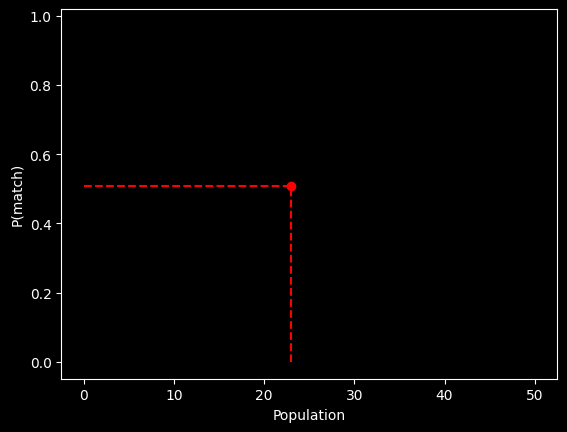

In [2]:
import math
import matplotlib.pyplot as plt

# Birthday problem figure.
fig = plt.Figure(figsize=(5, 5))

def shared_birthday_probability(num_people: int) -> float:
    numerator = math.factorial(365)
    denominator = math.factorial(365 - num_people) * 365 ** num_people
    return 1 - numerator / denominator

population = range(1, 51)

plt.plot(population,
         list(map(shared_birthday_probability, population)),
         color='k')
plt.plot(23, shared_birthday_probability(23),
         color='r', markersize=6, marker='o')
plt.hlines(y=[shared_birthday_probability(23)], xmin=0, xmax=23, linestyle='--', color='r')
plt.vlines(x=[23], ymin=0, ymax=0.5, linestyle='--', color='r')
plt.xlabel("Population")
plt.ylabel("P(match)")
plt.show

## Finding a Particular Pokémon

You find yourself in the Sinnoh region, scouring for a particular Pokémon. You tell your accompanying friend that the probability of finding the Pokémon you seek per searching instance is $\frac{1}{n}$, to which they reply that, on average, you need only search $n$ times to find your quarry. Intuitively that sounds sensible, but is it true?

What is the probability of success based on her logic? The probability of finding the Pokémon on your first try is:

$$
P(\text{Pokémon}) = \frac{1}{n},
$$

so naturally the probability of not finding the Pokémon on the first attempt is:

$$
P(\text{No Pokémon}) = 1 - \frac{1}{n}.
$$

We presume to think that each searching instance is independent. Your previous efforts have no bearing on future success. Henceforth, the probability of failing to find the right Pokémon after $n$ attempts is:

$$
P(\text{No Pokémon after } n \text{ tries}) = \left(1 - \frac{1}{n}\right)^n,
$$

meaning the probability of success by the $n^{th}$ attempt is merely 1 minus this probability:

$$
P(\text{Pokémon after } n \text{ tries}) = 1 - \left(1 - \frac{1}{n}\right)^n.
$$

Let's now graph this probability equation as a function of *n*...

In [ ]:
plt.Figure(figsize=(7, 5))

trials = range(1, 16)


def prob_success_n_trials(n: int):
    p_fail = 1 - (1 / n)
    return 1 - p_fail ** n


plt.plot(trials,
         list(map(prob_success_n_trials, trials)),
         linestyle='',
         marker='o',
         markersize=5,
         color='k')

plt.xlabel("Number of Searching Instances")
plt.ylabel("Probability of Success")

As $n$ gets larger, the probability of finding the Pokémon you're after steadily converges to a constant value of ~0.632. So to be certain you'll find your Pokémon you'll need to search more than *n* times. Although graphing it helps with intuition, we can discern a more accurate result by taking the limit of the probability function with respect to $n$:

$$
\lim_{n \to \infty} \left(1 - \left(1 - \frac{1}{n}\right)^n\right) = 1 - \frac{1}{e} = 0.632...
$$

This is the consequence of a special case where we have a probability of success as being one over the number of trials. Be careful: we are increasing the rarity of the Pokémon alongside the number of attempts we make, which is why the probability does not tend to infinity as we increase the number of attempts. We don't see this same convergence when the number of trials doesn't match the denominator. Let us consider flipping a coin 10 times, and managing to land 10 heads in a row. The probability of this happening is:

$$
P(\text{10 in a row}) = \frac{1}{2^{10}}= \frac{1}{1024}.
$$

So what is the probability of getting 10 in a row after 1024 tries? Bearing in mind that each trial is 10 coin flips...

$$
P(\text{10 in a row after 1024 tries}) = 1 - \left(1 - \frac{1}{1024}\right)^{1024} = 0.632 = 63.2\%,
$$

and if we were to try two thousand times?

$$
P(\text{10 in a row after 2000 tries}) = 1 - \left(1 - \frac{1}{1024}\right)^{2000} = 0.858 = 85.8\%.
$$

In summary, when the probability of success for an individual trial is $\frac{1}{n}$, the probability of success after $m$ tries is:

$$
P(\text{success after m tries}) = 1 - \left(1 - \frac{1}{n}\right)^m.
$$

## Clausius Definition of Entropy


### Calculating entropy (thermodynamically)

Can we get the same answer as in {numref}`sec:stat_entropy` by considering the thermodynamic approach?

Consider the isothermal expansion of a gas from $ V_1 \to V_2 = 2 V_1 $ through an isothermal process. What is the entropy change in this process?

[[FIG OF REVERSIBLE EXPANSION]]

From the first law (in {numref}`sec:isothermal`), we can immediately set:

$$
\Delta U = 0, \\
\therefore Q = W.
$$

We can substitute $Q_\text{rev}$ for $W$ in {eq}`stateful` to find an expression in terms of work:

$$
\Delta S = \int \frac{dQ_\text{rev}}{T} = \frac{W}{T}.
$$

[[ FIG OF INTEGRAL ON ISOTHERM ]]

$$
\begin{aligned}
W &= \int_{V_1}^{V_2} p\ dV \\
&= \int \frac{nRT}{V}dV \\
&= nRT \ln\frac{V_2}{V_1} \\
&= nRT \ln 2 \\
&= T \Delta S.
\therefore \Delta S &= nR \ln 2
\end{aligned}
$$



## Entropy Changes

### Entropy Change: Thermal Conduction

Heat $Q$ flows from a hot reservoir at temperature $T_h$ to a cold reservoir at temperature $T_c$.  
Both reservoirs remain at constant temperature.

The total entropy change is

$$
\Delta S = \Delta S_h + \Delta S_c \\
= -\frac{Q}{T_h} + \frac{Q}{T_c} \\
= Q\left(\frac{1}{T_c} - \frac{1}{T_h}\right)
$$

Since $T_h > T_c$, the quantity in brackets is positive, so

$$
\Delta S > 0.
$$

### Entropy Change: Calorimetric Process

Two bodies initially at temperatures $T_1$ and $T_2$ are brought into thermal contact and reach a common final temperature $T_f$.

The total entropy change is

$$
\Delta S = \Delta S_1 + \Delta S_2 \\
= \int \frac{\delta Q_1}{T_1} + \int \frac{\delta Q_2}{T_2}
$$

The temperature cannot be taken outside the integral because it changes during the process.

For ideal substances with constant specific heat:

$$
\Delta S = m_1 c_1 \ln\left(\frac{T_f}{T_1}\right) + m_2 c_2 \ln\left(\frac{T_f}{T_2}\right)
$$

If $T_1 > T_f$, then

$$
\ln\left(\frac{T_f}{T_1}\right) < 0
$$

If $T_2 < T_f$, then

$$
\ln\left(\frac{T_f}{T_2}\right) > 0
$$

It follows that

$$
\Delta S > 0.
$$

```{admonition} Example
:class: example

Equal masses of water at $0^\circ$C and $100^\circ$C are combined.

Final temperature: $T_f = 50^\circ$C.

Convert to Kelvin:

$$
T_1 = 373\,\text{K}, \quad
T_2 = 273\,\text{K}, \quad
T_f = 323\,\text{K}
$$

With $m_1 = m_2 = m$ and $c_1 = c_2 = c$:

$$
\Delta S
= mc \ln\left(\frac{323}{373}\right)
+ mc \ln\left(\frac{323}{273}\right)
$$

$$
\approx mc (\ln 0.866 + \ln 1.183)
$$

$$
\approx 0.10\, mc
$$

Thus,

$$
\Delta S > 0.
$$

```

### Entropy Change: Free Expansion

Consider a gas expanding freely from volume $V_1$ to $V_2$.

- The system is insulated  
- $Q = 0$  
- $W = 0$

From the First Law [[REF FIRSTLAW]]:

$$
\Delta U = Q - W = 0
$$

For an ideal gas, this implies $\Delta T = 0$.

To calculate the entropy change, we evaluate a reversible path between the same initial and final states:

$$
\Delta S = \int \frac{\delta Q_{\text{rev}}}{T}
$$

For an isothermal reversible expansion:

$$
Q_{\text{rev}} = \int p\,dV
$$

Using $p = \frac{nRT}{V}$:

$$
Q_{\text{rev}} = \int_{V_1}^{V_2} \frac{nRT}{V}\, dV \\
= nRT \ln\left(\frac{V_2}{V_1}\right)
$$

Therefore,

$$
\Delta S = \frac{Q_{\text{rev}}}{T} \\
= nR \ln\left(\frac{V_2}{V_1}\right)
$$

```{admonition} Example
:class: example

One mole of gas undergoes a free expansion from $V_1$ to $2V_1$.

$$
\Delta S = R \ln 2
$$

```

### Connection to Statistical Entropy

Recall Boltzmann’s formula:

$$
S = k_B \ln \Omega
$$

If available spatial states scale with volume:

$$
\Omega \propto \left(\frac{V}{V_{\min}}\right)^N
$$

Then

$$
\Omega_1 = \left(\frac{V_1}{V_{\min}}\right)^N \\
\Omega_2 = \left(\frac{V_2}{V_{\min}}\right)^N
$$

Taking the ratio:

$$
\frac{\Omega_2}{\Omega_1}
= \left(\frac{V_2}{V_1}\right)^N
$$

Taking the logarithm:

$$
\ln\left(\frac{\Omega_2}{\Omega_1}\right)
= N \ln\left(\frac{V_2}{V_1}\right)
$$

Therefore,

$$
\Delta S
= k_B \ln \Omega_2 - k_B \ln \Omega_1
= N k_B \ln\left(\frac{V_2}{V_1}\right)
$$

Using $N k_B = nR$:

$$
\Delta S = nR \ln\left(\frac{V_2}{V_1}\right)
$$

Thus the thermodynamic entropy change is recovered directly from the statistical definition.

## What is the entropy change → supercooling a liquid?

1 kg liquid at $-10^\circ\mathrm{C}$  →  1 kg solid at $-10^\circ\mathrm{C}$  

$$
T = 263 \ \mathrm{K}
$$

Latent heat:

$$
L = 333 \ \mathrm{kJ/kg}
$$

Heat released:

$$
\begin{aligned}
Q &= mL \\
  &= (1 \ \mathrm{kg})(333 \ \mathrm{kJ/kg}) \\
  &= 333 \ \mathrm{kJ}
\end{aligned}
$$

This heat is released into the environment.

$\,$

$$
\Delta S = \Delta S_{\text{system}} + \Delta S_{\text{environment}}
$$

$$
\Delta S
= \frac{\Delta Q_{\text{system}}}{T_{\text{system}}}
+ \frac{\Delta Q_{\text{env}}}{T_{\text{env}}}
$$

$$
\begin{aligned}
\Delta S
&= \frac{-333}{263}
+ \frac{333}{273} \\
&= -1.266 + 1.220 \\
&= -0.046 \ \mathrm{kJ/K}
\end{aligned}
$$

This appears to violate the Second Law.

$\,$

The formula

$$
S = \int \frac{\delta Q}{T}
$$

is valid only for reversible processes.

Freezing at $-10^\circ\mathrm{C}$ is irreversible because heat transfer occurs across a finite temperature difference.

To calculate the entropy change correctly, a reversible path between the same initial and final states must be constructed.

$\,$

Initial state: liquid at $263 \ \mathrm{K}$  

Final state: solid at $263 \ \mathrm{K}$  

Reversible path:

1. Heat liquid $263 \rightarrow 273 \ \mathrm{K}$  
2. Freeze at $273 \ \mathrm{K}$  
3. Cool solid $273 \rightarrow 263 \ \mathrm{K}$  

$\,$

### (1) Heat liquid 263 → 273 K

$$
\begin{aligned}
Q &= c_{\text{liq}} m \Delta T \\
  &= (4.2 \ \mathrm{kJ/kg\,K})(1 \ \mathrm{kg})(10 \ \mathrm{K}) \\
  &= 42 \ \mathrm{kJ}
\end{aligned}
$$

System entropy change:

$$
\begin{aligned}
\Delta S_{\text{system}}
&= \int \frac{\delta Q_{\text{rev}}}{T} \\
&= cm \int_{T_i}^{T_f} \frac{dT}{T} \\
&= cm \ln\left(\frac{T_f}{T_i}\right) \\
&= 4.2 \ln\left(\frac{273}{263}\right) \\
&= 0.157 \ \mathrm{kJ/K}
\end{aligned}
$$

Environment entropy change:

$$
\Delta S_{\text{env}}
= \frac{-42}{273}
= -0.154 \ \mathrm{kJ/K}
$$

Total for step (1):

$$
\Delta S_1
= 0.157 - 0.154
= 0.00288 \ \mathrm{kJ/K}
$$

$\,$

### (2) Freeze at 273 K

$$
Q = mL = 333 \ \mathrm{kJ}
$$

System entropy change:

$$
\Delta S_{\text{system}}
= \frac{-333}{273}
= -1.220 \ \mathrm{kJ/K}
$$

Environment entropy change:

$$
\Delta S_{\text{env}}
= \frac{+333}{273}
= +1.220 \ \mathrm{kJ/K}
$$

Total for step (2):

$$
\Delta S_2 = 0
$$

$\,$

### (3) Cool solid 273 → 263 K

$$
\begin{aligned}
Q &= c_{\text{ice}} m \Delta T \\
  &= (2.1 \ \mathrm{kJ/kg\,K})(1)(10) \\
  &= 21 \ \mathrm{kJ}
\end{aligned}
$$

System entropy change:

$$
\begin{aligned}
\Delta S_{\text{system}}
&= cm \ln\left(\frac{263}{273}\right) \\
&= 2.1 \ln\left(\frac{263}{273}\right) \\
&= -0.078 \ \mathrm{kJ/K}
\end{aligned}
$$

Environment entropy change:

$$
\Delta S_{\text{env}}
= \frac{+21}{273}
= 0.077 \ \mathrm{kJ/K}
$$

Total for step (3):

$$
\Delta S_3
= -0.00144 \ \mathrm{kJ/K}
$$

$\,$

### Total entropy change

$$
\begin{aligned}
\Delta S_{\text{total}}
&= \Delta S_1 + \Delta S_2 + \Delta S_3 \\
&= 0.00288 + 0 - 0.00144 \\
&= 0.00144 \ \mathrm{kJ/K}
\end{aligned}
$$

$$
\boxed{\Delta S_{\text{total}} = 0.00144 \ \mathrm{kJ/K} > 0}
$$

The Second Law is satisfied.

## The Second Law of Thermodynamics

(JL notes + textbook Section 20.5.)
JL:

### Entropy and the Second Law (Intuitive Picture)

The second law of thermodynamics is that the entropy of a closed system will increase or remain constant with time.

ΔS_closed ≥ 0

This means that heat always flows from systems with higher temperatures to ones with lower temperatures.

System 1 → Q → System 2  
T_h = 100 °C  
T_c = 0 °C

Goes to (remember that internal energy ≡ temperature)  
hot molecules move

ΔQ = Q  
T_f = 50 °C

With T_h < T_f < T_c.

## Back to Temperature

Initially we have:

System 1: 100 °C  
System 2: 0 °C

→

System 1: 50 °C  
System 2: 50 °C

The right question is: where are the hot molecules?

Initially we have certainty (S = 0), but this goes to a system with uncertainty (S > 0).

The change in entropy is greater than zero.

The uncertainty in the system has increased  
(associated with where the heat energy is).

### Second Law

An isolated system will evolve towards a state of thermal equilibrium.

The entropy of an isolated system will increase or remain constant with time.

$$
\Delta S_{\text{isolated}} \ge 0
$$

$\,$

### Example

Two systems at finite temperatures $T_H$ and $T_C$ exchange heat $Q$.

Show that this process does not violate the Second Law.

$\,$

For a system at constant temperature,

$$
\Delta S = \int \frac{\delta Q}{T}
$$

If $T$ is constant,

$$
\Delta S = \frac{1}{T} \int \delta Q
= \frac{\Delta Q}{T}
$$

$\,$

The total entropy change is

$$
\Delta S_{\text{total}}
= \Delta S_H + \Delta S_C
$$

$$
\Delta S_{\text{total}}
= \frac{\Delta Q_H}{T_H}
+ \frac{\Delta Q_C}{T_C}
$$

System $C$ receives heat $Q$, system $H$ loses heat $Q$.

$$
\Delta Q_H = -Q
\qquad
\Delta Q_C = +Q
$$

Therefore,

$$
\begin{aligned}
\Delta S_{\text{total}}
&= \frac{-Q}{T_H}
+ \frac{Q}{T_C} \\
&= Q\left(\frac{1}{T_C}
- \frac{1}{T_H}\right)
\end{aligned}
$$

Since

$$
T_H > T_C
$$

it follows that

$$
\left(\frac{1}{T_C}
- \frac{1}{T_H}\right) > 0
$$

Hence,

$$
\Delta S_{\text{total}} \ge 0
$$

The Second Law is satisfied.


## The Third Law of Thermodynamics